# Tutorial 3c: Stepped Optimization and DLS/LM

This tutorial covers the **Levenberg-Marquardt (DLS)** native solver in depth:

* How the LM algorithm works: `(JᵀJ + λI)Δx = -Jᵀr`
* Customising the `LevenbergController` (λ-schedule)
* Using `LineSearchController`
* Exact equality constraints via `NullSpaceStrategy`
* Bounds via `BoxBoundsStrategy` (the default)
* `GaussNewton` for the un-damped variant

**Prerequisite:** Tutorial 3b (method selection). [Tutorial 3d](Tutorial_3d_Inspecting_and_Controlling_a_Run.ipynb) covers observers and composable stopping in depth.

## 1. Setup

In [1]:
import copy
import numpy as np

from optiland import optic
from optiland.optimization import (
    minimize,
    OptimizationProblem,
    LevenbergController,
    LineSearchController,
    LevenbergMarquardt,
    GaussNewton,
    NullSpaceStrategy,
)

Build a cemented doublet as the working example.

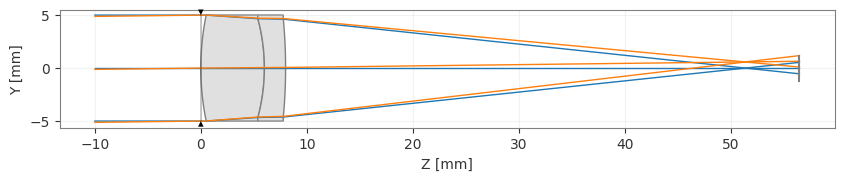

In [2]:
def make_doublet():
    lens = optic.Optic()
    lens.surfaces.add(index=0, thickness=np.inf)
    lens.surfaces.add(index=1, thickness=6.0, radius=25.0, material='N-BK7', is_stop=True)
    lens.surfaces.add(index=2, thickness=2.0, radius=-18.0, material='N-SF11')
    lens.surfaces.add(index=3, thickness=0.5, radius=-50.0)
    lens.surfaces.add(index=4, thickness=48.0)
    lens.surfaces.add(index=5)
    lens.set_aperture(aperture_type='EPD', value=10)
    lens.fields.set_type('angle')
    lens.fields.add(y=0.0)
    lens.fields.add(y=0.7)
    lens.wavelengths.add(value=0.4861)
    lens.wavelengths.add(value=0.5876, is_primary=True)
    lens.wavelengths.add(value=0.6563)
    return lens

lens = make_doublet()
_ = lens.draw()

## 2. The DLS algorithm

Levenberg-Marquardt minimizes a sum-of-squares merit function:

```
(JᵀJ + λI)Δx = -Jᵀr
```

Large `λ` gives a small gradient-like step (safe far from the solution); small `λ` gives a fast Gauss-Newton step (efficient near the solution). The `LevenbergController` adapts `λ` automatically.

## 3. Default DLS run

In [3]:
def make_problem(lens):
    problem = OptimizationProblem()
    for field in lens.fields.get_field_coords():
        input_data = {'optic': lens, 'surface_number': -1,
                      'Hx': field[0], 'Hy': field[1],
                      'num_rays': 5, 'wavelength': 0.5876, 'distribution': 'hexapolar'}
        problem.add_operand('rms_spot_size', target=0, weight=1, input_data=input_data)
    problem.add_operand('f2', target=100, weight=1, input_data={'optic': lens})
    for s in [1, 2, 3]:
        problem.add_variable(lens, 'radius', surface_number=s)
    problem.add_variable(lens, 'thickness', surface_number=4, min_val=30, max_val=80)
    return problem

problem = make_problem(lens)
result = minimize(problem, 'dls')
print(result)

Optimization started — initial merit = 2813.11
  iter     1 | merit = 1369.1
  iter     2 | merit = 110.031
  iter     3 | merit = 1.22387
  iter     4 | merit = 0.0565402
  iter     5 | merit = 0.0559991
  iter     6 | merit = 0.0559687
Optimization ended  — final merit = 0.0559687  (+100.00%)  [cost_tol=1.00e-03 (rel_change=5.43e-04)]
OptimizationResult(x=array([-0.69951857, -1.1348864 , -1.64752552,  7.        ]), success=True, status='cost_tol=1.00e-03 (rel_change=5.43e-04)', value=0.05596874258453386, initial_value=2813.1094190774606, improvement_pct=99.99801043136806, iterations=6, n_value_evals=12, n_jac_evals=6, wall_time_s=0.20683639985509217, history=None, backend='numpy', method='dls', resolved_from=None)


In [4]:
problem.info()

╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │                1.49461 │           99.9469 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ rms spot size  │        0 │              │              │        1 │             1 │   0.865 │   0.865 │          50.05 │
│  1 │ rms spot size  │        0 │              │              │        1 │             1 │   0.864 │   0.864 │          49.95 │
│  2 │ f2             │      100 │              │              │        1 │             1 │ 100

## 4. Custom `LevenbergController`

Tune `lam_init` (starting damping), `lam_factor` (adaptation speed), and `lam_max` (safety cap). A smaller `lam_init` starts more aggressively.

In [5]:
lens2 = make_doublet()
problem2 = make_problem(lens2)

# lam_factor_up / lam_factor_down control how fast λ adapts.
# A smaller lam_init starts more aggressively (closer to Gauss-Newton).
ctrl = LevenbergController(lam_init=1e-4, lam_factor_up=10.0, lam_max=1e10)
result2 = minimize(problem2, 'dls', controller=ctrl)
print(result2)

Optimization started — initial merit = 2813.11
  iter     1 | merit = 1369.1
  iter     2 | merit = 110.031
  iter     3 | merit = 1.22387
  iter     4 | merit = 0.0565402
  iter     5 | merit = 0.0559991
  iter     6 | merit = 0.0559687
Optimization ended  — final merit = 0.0559687  (+100.00%)  [cost_tol=1.00e-03 (rel_change=5.43e-04)]
OptimizationResult(x=array([-0.69951857, -1.1348864 , -1.64752552,  7.        ]), success=True, status='cost_tol=1.00e-03 (rel_change=5.43e-04)', value=0.05596874258453386, initial_value=2813.1094190774606, improvement_pct=99.99801043136806, iterations=6, n_value_evals=13, n_jac_evals=6, wall_time_s=0.2131300000473857, history=None, backend='numpy', method='dls', resolved_from=None)


## 5. Aggressive vs conservative `LevenbergController`

`LevenbergController` accepts three key knobs:

| Parameter | Meaning | Tip |
|-----------|---------|-----|
| `lam_init` | Starting λ — higher = more conservative first step | Decrease for well-conditioned problems |
| `lam_factor_up` | Multiplier when a trial step is rejected | Increase for extra robustness |
| `lam_factor_down` | Multiplier when a step is accepted | Decrease for faster trust-region expansion |
| `lam_max` | Safety cap — stops if λ exceeds this | Raise if you hit early termination |

> **Note:** `LineSearchController` is designed for gradient-based stepped optimizers that
> supply a pre-computed descent direction.  It is **not** compatible with
> `LevenbergMarquardt`, which computes its own direction from the normal equations.
> Use `LevenbergController` to tune DLS step size.

In [6]:
lens3 = make_doublet()
problem3 = make_problem(lens3)

# Conservative controller: high starting λ, slow trust-region expansion.
ctrl_conservative = LevenbergController(lam_init=1.0, lam_factor_up=10.0, lam_factor_down=0.5)
print('--- Conservative controller ---')
result3 = minimize(problem3, 'dls', controller=ctrl_conservative)
print(result3)

lens3b = make_doublet()
problem3b = make_problem(lens3b)

# Aggressive controller: low starting λ, fast trust-region expansion.
ctrl_aggressive = LevenbergController(lam_init=1e-5, lam_factor_up=5.0, lam_factor_down=0.1)
print('\n--- Aggressive controller ---')
result3b = minimize(problem3b, 'dls', controller=ctrl_aggressive)
print(result3b)

--- Conservative controller ---
Optimization started — initial merit = 2813.11
  iter     1 | merit = 1369.1
  iter     2 | merit = 392.266
  iter     3 | merit = 59.87
  iter     4 | merit = 5.17701
  iter     5 | merit = 0.364109
  iter     6 | merit = 0.112842
  iter     7 | merit = 0.0632317
  iter     8 | merit = 0.0500163
  iter     9 | merit = 0.0477566
  iter     9 | merit = 0.0477566
Optimization ended  — final merit = 0.0477566  (+100.00%)  [intrinsic_convergence]
OptimizationResult(x=array([-0.69726682, -1.13737318, -1.65920824,  7.        ]), success=True, status='intrinsic_convergence', value=0.047756575057808726, initial_value=2813.1094190774606, improvement_pct=99.99830235629179, iterations=9, n_value_evals=29, n_jac_evals=10, wall_time_s=0.36469609988853335, history=None, backend='numpy', method='dls', resolved_from=None)

--- Aggressive controller ---
Optimization started — initial merit = 2813.11
  iter     1 | merit = 70.2038
  iter     2 | merit = 0.994887
  iter   

## 6. `GaussNewton` (un-damped)

`method='gauss_newton'` uses un-damped Gauss-Newton steps (`λ = 0`). Converges fast near the solution but can diverge far from it. Useful as a fine-tuning pass after DLS.

In [7]:
lens4 = make_doublet()
problem4 = make_problem(lens4)
result4 = minimize(problem4, 'gauss_newton')
print(result4)

Optimization started — initial merit = 2813.11
  iter     1 | merit = 1269.28
  iter     2 | merit = 759209
  iter     3 | merit = 7.27145e+08
  iter     3 | merit = 7.27145e+08
Optimization ended  — final merit = 7.27145e+08  (-25848330.31%)  [intrinsic_convergence]
OptimizationResult(x=array([ 112.1041738 , -914.20811194, 1348.91046074,    7.        ]), success=True, status='intrinsic_convergence', value=727144627.8180732, initial_value=2813.1094190774606, improvement_pct=-25848330.31297855, iterations=3, n_value_evals=4, n_jac_evals=4, wall_time_s=0.10429050005041063, history=None, backend='numpy', method='gauss_newton', resolved_from=None)


## 7. Variable bounds (`BoxBoundsStrategy`)

Add `min_val`/`max_val` to `add_variable(...)`. With the default `bounds=True`, the optimizer clips/projects parameters at each step. Set `bounds=False` to disable.

In [8]:
lens5 = make_doublet()
problem5 = make_problem(lens5)

# Build a fresh problem with explicit radius bounds on all refractive surfaces
problem5_bounded = OptimizationProblem()
for field in lens5.fields.get_field_coords():
    input_data = {'optic': lens5, 'surface_number': -1,
                  'Hx': field[0], 'Hy': field[1],
                  'num_rays': 5, 'wavelength': 0.5876, 'distribution': 'hexapolar'}
    problem5_bounded.add_operand('rms_spot_size', target=0, weight=1, input_data=input_data)

problem5_bounded.add_operand('f2', target=50, weight=1, input_data={'optic': lens5})

for s in [1, 2, 3]:
    problem5_bounded.add_variable(lens5, 'radius', surface_number=s, min_val=10, max_val=200)

problem5_bounded.add_variable(lens5, 'thickness', surface_number=4, min_val=30, max_val=80)

result5 = minimize(problem5_bounded, 'dls', bounds=True)
print(result5)

Optimization started — initial merit = 9.58183
  iter     1 | merit = 0.0387353
  iter     1 | merit = 0.0387353
Optimization ended  — final merit = 0.0387353  (+99.60%)  [intrinsic_convergence]
OptimizationResult(x=array([-0.74433136, -0.9       , -0.9       ,  3.62798825]), success=True, status='intrinsic_convergence', value=0.03873525942117496, initial_value=9.581831818837673, improvement_pct=99.59574264969854, iterations=1, n_value_evals=22, n_jac_evals=2, wall_time_s=0.1350461000110954, history=None, backend='numpy', method='dls', resolved_from=None)


## 8. `NullSpaceStrategy` for exact equality

`NullSpaceStrategy` enforces a user-supplied equality constraint `h(x) = 0` at every
accepted step via null-space projection followed by Newton restoration.

The constraint function takes the current parameter vector `x` (same ordering as the
problem variables) and must return a 1-D array whose values equal zero on the feasible
manifold.  Below we constrain the effective focal length to stay at 100 mm throughout
the optimization.

In [9]:
lens6 = make_doublet()
problem6 = make_problem(lens6)

# Equality constraint: keep f2 = 100 mm throughout the run.
# h(x) must return 0 on the feasible manifold.
def efl_constraint(x):
    problem6.set_variable_vector(x)
    return np.array([float(lens6.paraxial.f2()) - 100.0])

result6 = minimize(problem6, 'dls', constraints=NullSpaceStrategy(equality_fn=efl_constraint))
print(result6)

Optimization started — initial merit = 2813.11
  iter     1 | merit = 1369.1
  iter     2 | merit = 1.75612
  iter     3 | merit = 0.0145533
  iter     4 | merit = 0.000107531
  iter     5 | merit = 2.05373e-05
  iter     6 | merit = 1.96822e-05
  iter     7 | merit = 1.96761e-05
Optimization ended  — final merit = 1.96761e-05  (+100.00%)  [cost_tol=1.00e-03 (rel_change=3.08e-04)]
OptimizationResult(x=array([ 0.53764057,  0.53700287, -2.56495163,  7.        ]), success=True, status='cost_tol=1.00e-03 (rel_change=3.08e-04)', value=1.9676134489178897e-05, initial_value=2813.1094190774606, improvement_pct=99.99999930055566, iterations=7, n_value_evals=12, n_jac_evals=7, wall_time_s=0.2695140999276191, history=None, backend='numpy', method='dls', resolved_from=None)


In [10]:
problem6.info()

╒════╤════════════════════════╤═══════════════════╕
│    │   Merit Function Value │   Improvement (%) │
╞════╪════════════════════════╪═══════════════════╡
│  0 │               0.899038 │            99.968 │
╘════╧════════════════════════╧═══════════════════╛
╒════╤════════════════╤══════════╤══════════════╤══════════════╤══════════╤═══════════════╤═════════╤═════════╤════════════════╕
│    │ Operand Type   │   Target │ Min. Bound   │ Max. Bound   │   Weight │   Eff. Weight │   Value │   Delta │   Contrib. [%] │
╞════╪════════════════╪══════════╪══════════════╪══════════════╪══════════╪═══════════════╪═════════╪═════════╪════════════════╡
│  0 │ rms spot size  │        0 │              │              │        1 │             1 │   0.671 │   0.671 │          50.04 │
│  1 │ rms spot size  │        0 │              │              │        1 │             1 │   0.67  │   0.67  │          49.96 │
│  2 │ f2             │      100 │              │              │        1 │             1 │ 100

## 9. Summary

| Feature | How to enable |
|---------|---------------|
| Default DLS | `minimize(problem, 'dls')` |
| Custom λ schedule | `controller=LevenbergController(lam_init=..., lam_factor_up=..., lam_factor_down=...)` |
| Un-damped Gauss-Newton | `minimize(problem, 'gauss_newton')` |
| Box bounds | `add_variable(..., min_val=..., max_val=...)` + `bounds=True` |
| Exact equality projection | `constraints=NullSpaceStrategy(equality_fn=...)` |

**Next:** [Tutorial 3d](Tutorial_3d_Inspecting_and_Controlling_a_Run.ipynb) — observers, stopping criteria, and run control.